<a href="https://colab.research.google.com/github/elean23/git-lesson/blob/main/Module4Capsule2_abiertaUGR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

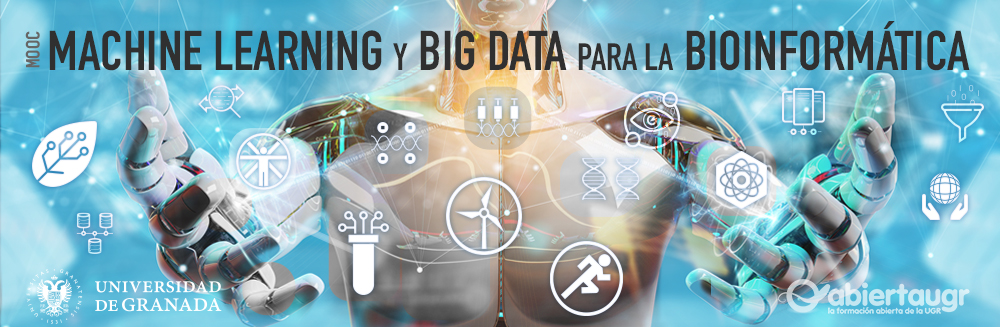
## **Module 4 - Supervised Learning: Regression Techniques**.
## **4.2 Standard regression methods**

**Authors**:

*By* Rafael Alcalá

Professor at the University of Granada, , Andalusian Inter-University Institute in Data Science and Computational Intelligence (DaSCI).

by Augusto Anguita-Ruiz

Postdoctoral Research Fellow at Barcelona Institute for Global Health- ISGlobal

**Reminder: Introduction to NoteBook**.

In this *NoteBook* you will be guided, step-by-step, through loading a dataset to the descriptive analysis of its contents. The Jupyter NoteBook (*Python*) is an approach that combines text blocks (like this one) and code blocks or cells. The great advantage of this system is its interactivity because cells can be executed to directly check the results they contain.

**Very important**: the order of the instructions is fundamental and so each cell in this NoteBook must be executed sequentially. If any are omitted, the program may throw an error and so if there is any doubt, you will have to start from the beginning again.

First, it is very important to select “*Open in draft mode*” (draft mode) at the top left at the beginning. Otherwise, for security reasons, you will not be allowed to execute any code blocks. When the first of the blocks is executed, the following message will appear: “*Warning: This NoteBook was not created by Google*”. Don’t worry, you can trust the contents of the NoteBook and click on “*Run anyway*”.

Let’s start!

Click on the “*play*” button on the left side of each code cell. Remember that lines beginning with a hashtag (#) are comments and do not affect the execution of the script. You can also click on each cell and press “Ctrl+enter” (“Cmd+Enter” on Mac). Each time you execute a block, you will see the output just below it. The information is usually always the last statement, along with any *print()* commands present in the code.

## **INDEX**

In this *Notebook*:
1. We learn the general concepts of Simple and Multiple Linear regression technique.
2. We will apply multiple linear regression as the first tool used to study any regression problem, following examples with our insulin resistance estimation problem.
    
Contents:
1. [Linear regression](#etiquetaA)
2. [2.	Installation of R and libraries, and reading the childhood obesity data](#etiquetaB)  
3. [First contact with the problem and study of the variables of greatest interest](#etiquetaC)  
4. [Additive selection of variables: backward stepwise regression](#etiquetaD)   
5. [Interactions and non-linearity](#etiquetaE)   
6. [Cross-validation](#etiquetaF)   
7. [Bibliography](#etiquetaG)
  

## **1. LINEAR REGRESSION <a id='etiquetaA'></a>**

The first **regression method** we will address in this module is **linear regression**, which is considered as a simple approach in the field of supervised learning. In **linear regression**, it is assumed that **dependence of the output variable $Y$** (in our case study of childhood obesity represented by the variable *HOMA-IR*) **on the input variables $X_1, X_2, \dots, X_p$** (all other variables in our problem) **is linear**. Although it may seem too simplistic, **linear regression** is extremely useful both conceptually and in practice. In this capsule we will see how to use it to study a data set and draw useful conclusions about the behaviour of the data, without prejudice to the use of other (supposedly or theoretically more powerful) techniques to obtain better-fitting models. First of all, we will distinguish between **simple or multiple linear regression**.

### **1.1 Simple linear regression basics**

In a **simple linear regression**, using **a single input variable $X$** we assume the following model,

<center>$Y = \beta_0 + \beta_1 X + \epsilon,$ </center>

where $\beta_0$ and $\beta_1$ are two unknown constants that represent the independent term and the slope of a linear function (a straight line) respectively. These constants are known as **coefficients or parameters**. In this context, $$epsilon$ refers to the **error term of the estimate**.

Given an estimate of $\hat{\beta_0}$ and $\hat{\beta_1}$ for the model **coefficients**, we can predict future values of the output variable $Y$ using,

<center>$\hat{y} = \hat{\beta_0} + \hat{\beta_1} x,$ </center>

where $\hat{y}$ represents a prediction of $Y$ based on $X = x$. The hat symbol denotes that we are referring to **estimated values** (rather than actual or observed values). The values of $\hat{\beta_0}$ and $\hat{\beta_1}$ are obtained through the **least squares technique**, which obtains the coefficients that minimise the error made for each available instance in a training data set.  In other words, with **least squares**, the optimal values of the **coefficients** that minimise the value of **RMSE** are always obtained.

### **1.2 Basic concepts of multiple linear regression**

In the case of **multiple linear regression**, using **more than one input variable $X$** we assume the following model,

<center>$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon,$ </center>

interpreting each coefficient $beta_j$ as the average effect on $Y$ of a unit increase in $X_j$, keeping the rest of the input variables fixed. The ideal case is when the input variables $X's$ are not correlated with each other (no collinearity), as this would imply certain interpretation problems. However, if the learning process is carried out step by step, taking into account the statistical values obtained on these coefficients, the variables that are correlated with each other are eventually eliminated. In **multiple linear regression**, the estimation of the coefficients is also performed using the **least squares technique**, minimising the error of the predictions on the training data set.

### **1.3 Evaluation of the goodness of fit of the estimation coefficient**

This technique generates certain **statistical values** that will allow us to answer questions such as whether there is at least one input variable ($X_j$) that has a linear relationship with the output variable ($Y$). If this is the case, which ones? Here we will refer to two **statistical values**:

* The *F-statistic*: This is a value obtained for the regression model as a whole, rather than for each of the input variables. The extent that its value departs from 1 (either upwards or downwards) indicates that at least one input variable has a linear relationship with the output variable. If this value is close to 1, we can directly discard the modelled linear regression since there will be no input variable ($X_j$) with a linear relationship with the output ($Y$). This parameter is particularly important in problems with many input variables which may include variables that initially appear to be relevant but are eventually found not to be. Thus, the **F statistic is** the first parameter we must study when performing a regression. After that, **we only continue with the process** if its value is not close to 1.

* **The p-values of the t-statistics**: This value is a parameter associated with each of the coefficients, although a global p-value is also obtained for the complete regression model. The p-values will indicate whether the coefficient $beta_j$ of each input variable ($X_j$)  is relevant or if, on the contrary there is a high probability that it could actually be zero ($beta_j \approx 0$ implies that the variable in question has no linear relationship with the output variable and therefore, should be eliminated from the model). This happens when the p-value for the coefficient exceeds $0.1$ or $0.15$, indicating that the variable might be irrelevant ($beta_j \approx 0$).


### **1.4 Assessing the goodness of fit of the model**

As mentioned in the previous capsule, the value of the **Coefficient of Determination $R^2$** can fall between 0 and 1, with a value of 1 indicating a perfect model fit (zero error) and 0 indicating a fit with the worst possible error. To **compare several linear regression models with each other**, the value of **$R^2$** obtained in each of them is usually considered. However, because the number of coefficients $\beta_j$ of the different models must be taken into account, in order to compare models with different numbers of input variables, actually, we would have to look at the so-called adjusted **$R^2$$** (which already takes them into account during its calculation).

If we want to compare a **linear regression model** with models obtained by **other regression techniques** (e.g., KNN, neural networks, M5, ...) we must use **the value of RMSE**. Let us remember that, on the other hand, **$R^2$** is a relative parameter and that not all techniques allow its calculation.

### **1.5 Choosing the relevant input variables**

The usefulness of linear regression depends very much on the variables chosen to learn its **coefficients**. In principle, these must be manually selected because not all possible combinations of variables can be examined. For example, for a problem **with 40 input variables**, $p = 40$, we would have $2^p$ combinations of different models **(over a trillion combinations)**. **To decide which variables should be considered in the final model, there are **two approaches** commonly used:

1.	**Forward selection**: This procedure consists of starting by building the **null model** which contains the independent term but no input variables, and then running simple linear regressions in parallel between the output/dependent variable $Y$ and each of the input variables $X_j$. We will then add the input variable that results in **the lowest error among all models tested (the one with the highest adjusted $R^2$)** to the null model. The procedure is then continued until some stopping rule is satisfied. For example, adding any of the remaining variables **gives a p-value above some threshold for that variable (>$0.1$ or $0.15$ for example)**. **IMPORTANT!!!:** the variables must be added one at a time and NEVER several at once. Each time a variable is added, it contributes to explaining a part of the data and, so the p-values of the other variables may change and no longer be relevant as there is no longer a need to explain that part of the data.

2.	**Backward selection**: Start with all the variables in the model and then eliminate the input variable with the highest p-value (i.e., the least statistically significant variable), and fit the new model with the remaining $(p - 1)$ variables. In the next round, we again remove the variable with the highest p-value, and so on, until a stopping rule is reached. For example, we can stop when all the input variables that make up the model have a significant value (e.g., a p-value below $0.1$ or $0.15$). **IMPORTANT!!!:** the variables must be eliminated one at a time and NEVER several at once. Each time a variable is eliminated, we make it easier for one of the remaining variables to adequately explain part of the data so that they can go from being a variable of little relevance (or even an annoying variable with a very high p-value) to an essential one. Therefore, these variables would be lost if we were to remove several at once. If this process is followed strictly, it will solve most of the correlation problems (collinearity) between the input variables.

It is important to consider that the **independent term** of the regression does not come into play in either of these two approaches, and so it will never be removed from the model.

There are other possibilities besides these two approaches, such as calculating the correlations of all the input variables with the output variable, and keeping a small set of the best ones; or, for example, applying one of the existing variable selection algorithms. **Unfortunately, none of these ensures that the best existing combination is reached**.

In this course, **we recommend using backward selection when the number of variables is not too large**, and **forward selection when there are many variables** (automating the choice of the variable to be included in each step).

Using either of these two approaches will allow us to do exactly what we set out to do with regression: **study a data set and be able to draw useful conclusions** about the behaviour of the data, even if other, more versatile types of techniques are eventually applied. Thus, in our **dataset on obesity and insulin resistance in children**, we will apply **the backward selection approach**.

### **1.6 Extensions of the linear model.Eliminating the additive assumption: interactions and non-linearity.**

To deal with the **non-linearity** of the data existing in most real-life data sets, new **interaction terms** (variables with positive synergy that enhance each other) or **non-linearity** (variables with quadratic, logarithmic growth, etc.) can be considered. In order to study these behaviours in a **linear regression** we must use one of two different terms, as outlined below.

* **Interactions** (terms whose behavior is not additive): these interaction terms are presented in regression models as **$X_1$ $*$ $X_2$**, and represent how the change in two or more variables jointly causes changes in the output variable $Y$ greater than they would do separately. For example: it is known that investing 5000 euros of advertising in $radio$ and another 5000 in $television$ leads to much higher sales of a product than if 10000 euros are invested directly in either of the two media unilaterally. Including a new multiplicative term of the type $radio*television$ in the regression model would allow us to adequately explain such a non-linear phenomenon.

* **Other non-linear terms**: Often the relationship between an input variable and the output variable is not linear but quadratic, cubic, logarithmic, exponential, etc. Including a term that matches this type of relationship can help to adequately explain these non-linear phenomena.

However, the **principle of hierarchy** must be respected in every case. That is, if a new variable $(X_5)^3$  is included for $X_5$  and its p-value indicates that this cubic term is relevant, then $(X_5)^2$  and $X_5$  must also be included, even if their p-values are not significant; not including them would represent a serious mistake. The same rule follows in the case of interactions: if a new variable $(X_1 * X_2 * X_6)$ is included and retained because the three variables complement each other (meaning that the p-value for that interaction term is significant), then $(X_1 * X_2)$, $(X_1 * X_6)$, $(X_2 * X_6)$, $X_1$, $X_2$, and $X_6$ must also be included (irrespective of their p-values).

## **2.	INSTALLATION OF R AND LIBRARIES , AND READING THE CHILDHOOD OBESITY DATA <a id='etiquetaB'></a>**

As explained in the previous capsule, we must run the following three code cells before starting the linear regression algorithm.

In [ ]:
# Estimated execution time: approx. 20 seconds.

### Installing R on Google Colab notebooks ###
!apt-get update
!apt-get install r-base
!pip install rpy2==3.5.1
%load_ext rpy2.ipython
print ("Instalación de R en Google Colab terminada")

In [ ]:
# Estimated execution time: 4 seconds approx (not needing to import kknn and Cubist).
# Libraries needed:
# ISLR for multivariate linear regression
# kknn for k-nearest neighbours regression
# Cubist for M5-based regression models

%%R
### Installation of required libraries
#install.packages(c("ISLR", "kknn", "Cubist"))
install.packages(c("ISLR")) #kknn and Cubist will be used in the following capsule
print ("Installation of R libraries for this module completed")

### Import the required libraries
require(ISLR)
###require(kknn)
##require(Cubist)
print ("Import of the R libraries for this module is finished")

In [ ]:
# Estimated execution time: 2 seconds approx.

%%R
### Loading
data <- read.csv(url("https://drive.google.com/uc?id=1GO2NBxYw54K6HkN-YgXbNadrLo5O6-0u"))

### Visualisation of a small part of the data
head(data)

As we can see, the head command offers us a visualization of the available data for the first 6 individuals/instances of the set. In this visualization, we can identify variables such as the sex of the individuals (coded as 0 for boys or 1 for girls), the pubertal stage (represented by the Tanner variable, and coded as 0 for the pre-pubertal and 1 for pubertal), or the blood pressure (represented by the variables DBP for diastolic blood pressure and SBP for systolic blood pressure). As shown, there are also variables for a sedentary lifestyle, and light, moderate, or vigorous physical activity. The remaining abbreviated variables refer to: BMI (body mass index); WC (waist circumference); TAG (triglycerides); HDL (high-density lipoprotein or ‘good’ cholesterol); and LDL (low-density lipoprotein or ‘bad’ cholesterol), with the latter three being expressed in milligrams/deciliter of blood.

## **3. INITIAL ASSESSMENT OF THE PROBLEM AND STUDY OF THE VARIABLES OF GREATEST INTEREST <a id='etiquetaC'></a>**

Once we have imported the libraries and read the data, we are ready to see **which variables are the most promising for applying linear regression to this problem**. To study which variables best explain the behavior of HOMA-IR as the output variable, we could **calculate the correlations** between it and each of the input variables (using the command: “*cor(data)*”), allowing us to choose those that are most correlated.

In our case, implementing this procedure on our data set shows that the correlation of SBP with HOMA-IR was higher than for other input variables (e.g., Sex). Nonetheless, at the end of this capsule we will see that, unlike Sex, SBP will eventually be eliminated from the final model. This can be explained by the fact that construction of the final model does not only depend on the individual correlation of each input variable with the output variable but rather, on the contribution of each variable with respect to the rest of the selected variables. If what can be explained by one input variable is already better explained by another, the former should not become part of the final model.

An alternative to the above is to **graphically show the relationship of each input variable with respect to the output variable**, HOMA-IR. Thus, we can visually observe not only whether their relationship is approximately linear, but also the shape of the point cloud. For example, we could see whether a variable exhibits quadratic or logarithmic behavior, and therefore it would be more appropriate to include these terms in the model. In our case study, we will opt for the **second approach** because it is considered more informative. The following R code block iteratively plots, in order, all the input variables with respect to the output variable (HOMA-IR).

**NOTE**: From here on it is important that you also read the comments included within the code for a better understanding of the process.


In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
### Display of the variable with respect to HOMA
temp <- data
plotY <- function (x,y) {
	plot(temp[,y]~temp[,x], xlab=paste(names(temp)[x]," X",x,sep=""), ylab=names(temp)[y])
}
par(mfrow=c(4,4)) #If margin too large => (5,3)
x <- sapply(1:(dim(temp)[2]-1), plotY, dim(temp)[2])
par(mfrow=c(1,1))

#cor(data) # Descomentar si queremos ver los valores concretos de correlación

As a result, we can see how, despite showing some scatter in the data, the variables $BMI$, $WC$, and $Height$ appear to be the most promising given that they show a relatively linear relationship with $HOMA$. This scatter is a sign that there is no single explanatory factor for the value of insulin resistance ($HOMA-IR$). In addition, all three variables show some non-linearity, a behavior that was most noticeable for $BMI$, which seems to show a quadratic relationship to some extent. In the following code blocks we will focus on these three variables and apply a simple linear regression to each of them as our first line of analysis. These code blocks launch a simple linear regression between $HOMA$ and $BMI$, $Height$, or $WC$, respectively.

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
### Obtaining the model. Function lm() from ISLR package.
### Y=HOMA, X's=BMI (body mass index) -> formula: HOMA ~ BMI
fitLM <- lm(HOMA ~ BMI, data=data)

### Line display (blue, estimated values) vs actual values (black, observed values).
yprime = predict(fitLM,data)
plot(data$HOMA~data$BMI)
points(data$BMI,yprime,col="blue",pch=20)

### Coefficients (Estimate), p-values (Pr(>|t|)), Adjusted R2 (Adjusted R-squared),
### F-statistic and p-value (F-statistic and p-value)
summary(fitLM)

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
### Idem for the Height variable
fitLM <- lm(HOMA ~ Height, data=data)
yprime = predict(fitLM,data)
plot(data$HOMA~data$Height)
points(data$Height,yprime,col="blue",pch=20)
summary(fitLM)

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
### Idem for the variable WC (waist circumference)
fitLM <- lm(HOMA ~ WC, data=data)
yprime = predict(fitLM,data)
plot(data$HOMA~data$WC)
points(data$WC,yprime,col="blue",pch=20)
summary(fitLM)

As a result, we can observe that the **p-values** associated with the **coefficients** of the three variables (column with name "$Pr(>||t|)$") clearly indicate that all **three are related to insulin resistance** (as they acquire p-values well below 0.1). Although it is the regression model based on ($BMI$) that explains more variability in $HOMA$ (according to its adjusted **$R^2$ value**), it is true that the value is not very high (0.3458).


Next, we will repeat the variable selection process but this time implementing the aforementioned **top-down approach**, which is applicable here because we only have 15 input variables.

## **4. STEPWISE VARIABLE SELECTION: BACKWARD STEPWISE REGRESSION <a id='etiquetaD'></a>**

In this section, we are going to leave behind **simple linear regressions** and move on to consider **multiple regression** models. As already indicated, we will follow a **descending variable selection** approach. The steps are shown one-by-one in the following code blocks so that the decisions made at each point in time can be tracked.

As explained in the previous sections, variables selected by including all them inthe model by applying a **backward approach**. This is achieved in *R* by means of the (*Y ~ .*) command, where the dot indicates "*all the available input variables in the dataset*".

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
### Obtaining the model. Y=HOMA, X's=All -> formula: HOMA ~ .
fitLM <- lm(HOMA ~ ., data=data)

### Reminder:
### Coefficients (Estimate), p-values (Pr(>|t|)), Adjusted R2 (Adjusted R-squared),
### F-statistic and p-value (F-statistic and p-value)
summary(fitLM)

Once we have obtained the **multiple linear regression** model with all the input variables, it is essential we not overlook the value obtained for the **F statistic**; this should be the first thing we check. As explained at beginning of this capsule, if the value of $F$ is close to 1 and/or its accompanying p-value exceeds $0.1$ or $0.15$, none of the variables used present a linear relationship with the output variable (HOMA-IR in our case). This interpretation **will always be independent of the individual p-value** obtained for each coefficient, which could mislead us until we eliminate redundant or uninformative input variables; in this situation, we would stop the linear regression analysis and look for an alternative regression technique. However, as we already knew from the initial values obtained in the previous section, this is not the case for our data set.

Checking the **p-values** obtained after this first step, we can see that the next step would be to eliminate the $Age$ variable because it has the highest p-value, equal to $0.89656$. An interesting detail is that the adjusted **$R^2$** of the complete model improves with respect to the **$R^2$** obtained for the simple linear regression models of the previous section (reaching a value of $0.4876$). To eliminate the $Age$ variable from the complete model in R, we use the command with the subtraction sign "-" in the formula, thus obtaining the new model.

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
### Obtaining the model. Y=HOMA, X's=All-Age -> formula: HOMA ~ .-Age
fitLM <- lm(HOMA ~ .-Age, data=data)

summary(fitLM)

After removing $Age$, we can see how the new **adjusted $R^2$** of the model improves because we removed a variable that did not contribute anything to the model. In view of these results, the next step will be to eliminate the $Moderate$ physical activity variable.

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
### Same as above -Moderate
fitLM <- lm(HOMA ~ .-Age-Moderate, data=data)
summary(fitLM)

As non-informative variables are removed, we can see how the **adjusted $R^2$ value** of the resulting model continues to incrementally improve. Next, we will eliminate the $Vigorous$ variable which refers to the daily number of minutes of $vigorous physical activity the children had engaged in.

At this point it is clear how to go about the procedure of eliminating non-informative variables one-by-one. This process should always be done in this way, even if it is tedious. In the following section we will show the steps we must take next to reach the last step (final model), which we will then run to see the final result. Please also remember to carefully read the comments in the following code



In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
#fitLM <- lm(HOMA ~ .-Age-Moderate-Vigorous, data=data)
#summary(fitLM)
#fitLM <- lm(HOMA ~ .-Age-Moderate-Vigorous-SBP, data=data)
#summary(fitLM)
#fitLM <- lm(HOMA ~ .-Age-Moderate-Vigorous-SBP-Tanner, data=data)
#summary(fitLM)

### In the above model already all p-values could be considered correct.
### For simplicity we have continued to remove while the adjusted R2 has hardly been affected.
#fitLM <- lm(HOMA ~ .-Age-Moderate-Vigorous-SBP-Tanner-Light, data=data)
#summary(fitLM)
#fitLM <- lm(HOMA ~ .-Age-Moderate-Vigorous-SBP-Tanner-Light-Sedentary, data=data)
#summary(fitLM)

### From here R2 would start to get significantly worse.
### We stop and reformulate for readability by indicating the selected input variables in an additive way.
### This model is equivalent to the one immediately above but shows clearly what is selected
fitLM <- lm(HOMA ~ BMI+Height+TAGmgDL+Sex+WC+LDLCmgDL+HDLCmgDL+DBP, data=data) #See that the dot is no longer included
summary(fitLM)

As a result, we obtain a model with 8 input variables and an **adjusted $R^2$** of 0.4861.

## **5. INTERACTIONS AND NON-LINEARITY <a id='etiquetaE'></a>**



Once we have selected the input variables to be incorporated into our **linear model**, we will try to explain the **non-linear** part of the data by adding **interactions and other non-linear terms**. To assess these interactions, we rely on our prior knowledge of the problem. For example, in a case of a known genetic interaction between two genetic variants, it would be appropriate to introduce an interaction term between the two to model their effect on the output variable. Where there is no prior information on any interaction phenomena, we can also be guided by logic or intuition, depending on the meaning of the input variables. If we still cannot find any possible interactions, we can randomly test the variables shown to be most significant (trial-and-error). However, this procedure is not a trivial and depends on our own skill and experience.

In our case study on childhood obesity, we will evaluate whether there is positive synergy (multiplicative factors, $∗$) between the triglyceride variable and the two cholesterol metrics (because they all belong to the lipid profile).


In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
### Interactions between triglycerides and cholesterols
fitLM <- lm(HOMA ~ BMI+Height+TAGmgDL+Sex+WC+LDLCmgDL+HDLCmgDL+DBP+TAGmgDL*HDLCmgDL*LDLCmgDL, data=data)
summary(fitLM)

Note that the use of operators already includes all the hierarchy terms. If it did not, we would have to add them by hand before looking at any p-values or making any decisions. We can see that the term *TAGmgDL:LDLCmgDL:HDLCmgDL* has an exceptionally bad p-value ($0.961424$), indicating that this hypothesized interaction was not pertinent.

We will now retest the model with the height and waist circumference values.

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
### Interactions between height and waist circumference
fitLM <- lm(HOMA ~ BMI+Height+TAGmgDL+Sex+WC+LDLCmgDL+HDLCmgDL+DBP+Height*WC, data=data)
summary(fitLM)

In this case we can see how the interaction explains part of the **non-linearity** given that a p-value of less than 0.1 was obtained. Therefore, in principle we will retain this as part of the model.

Finally, we must check for other **non-linear** terms. In this case, since we initially plotted all the input variables with respect to the output variable $HOMA-IR$, it is much easier to determine certain types of non-linear behavior visually. Of note, we saw that $HOMA-IR$ appeared to have a quadratic relationship with $BMI$. Therefore, we will also try to include this term in the model. This can be achieved using the $I(.)$ function in R, denoting the power as follows $I(X_j \hat{} exponent)$, in our case $I(BMI \hat{} 2)$. The $I(.)$ function does not automatically generate the hierarchy terms and so, before we can even look at the model, we must make sure that the formula contains all the hierarchy terms. In our case, the hierarchy terms would be $BMI + BMI^2 + Height + WC + Height*WC$.

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
### Interactions between height and waist circumference, plus BMI^2
fitLM <- lm(HOMA ~ BMI+Height+TAGmgDL+Sex+WC+LDLCmgDL+HDLCmgDL+DBP+Height*WC+I(BMI^2), data=data)
summary(fitLM)

Again, terms with high p-values appear, as is the case for $Height*WC$. The interaction was trying to explain what the quadratic $BMI$ term now explains better. We will therefore remove the now non-significant interaction. Recall that the BMI variable was already clearly showing a non-linear quadratic appearance in the graph.

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
fitLM <- lm(HOMA ~ BMI+Height+TAGmgDL+Sex+WC+LDLCmgDL+HDLCmgDL+DBP+I(BMI^2), data=data)
summary(fitLM)

According to the new model, $DBP$ would also now have to be eliminated.

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
fitLM <- lm(HOMA ~ BMI+Height+TAGmgDL+Sex+WC+LDLCmgDL+HDLCmgDL+I(BMI^2), data=data)
summary(fitLM)

And finally $HDLCmgDL$ must also be removed.

In an additional line of code, we have also included how to calculate the **RMSE** metric for a linear regression model (which did not appear in the *output* of the results offered by the *summary* command).

In [ ]:
# Estimated execution time: approx. 3 seconds.

%%R
fitLM <- lm(HOMA ~ BMI+Height+TAGmgDL+Sex+WC+LDLCmgDL+I(BMI^2), data=data)

### RECM calculation
yprime = predict(fitLM,data)
cat('\nRMSE:', sqrt(sum((data$HOMA-yprime)^2)/length(yprime)), "\n") #RECM->RMSE

summary(fitLM)

Visualization:

In [ ]:
#yprime = predict(fitLM,data)

%%R
plot(data$HOMA~data$BMI)
points(data$BMI,yprime,col="blue",pch=20)


Finally, we have arrived at **adjusted $R^2$** of 0.6092 when we had started at 0.3458. But the most important thing is not the value itself but rather, what we were able to learn about the data and our problem based on statistical values. The main conclusion we can draw is that a high body mass index in children is one of the main risk factors for insulin resistance. Even if the conclusion is that we must rethink the problem with new variables and measurements, coming to this realization would still represent a big step.

## **6. CROSS- VALIDATION <a id='etiquetaF'></a>**

Once we have obtained the best formula for applying the parametric fit (regression model), if we want to estimate new values of the output variable and compare its predictive ability with other models, as explained in Module 3 (*Data science and machine learning*), we must apply a cross-validation. In the following code, we show how this can be achieved.

In [ ]:
%%R

set.seed(123456)
k <- 5
data$kfold <- sample(1:k, nrow(data), replace = T)

performances <- c()

# One iteration per fold
for (fold in 1:k){
  # Training set is created for iteration
  training_set <- data[data$kfold != fold,]
  nombres <- names(training_set)
  tam <- length(nombres)-1
  training_set <- training_set[,nombres[1: tam]]

  # Create test set for this iteration
  # Subset all the datapoints where .folds matches the current fold
  testing_set <- data[data$kfold == fold,]
  nombres <- names(testing_set)
  tam <- length(nombres)-1
  testing_set <- testing_set[,nombres[1: tam]]

  ## Training the model for iteration
  model <- lm(HOMA ~ BMI+Height+TAGmgDL+Sex+WC+LDLCmgDL+I(BMI^2), data=training_set)

  ## Calculating test error
  yprime <- predict(model, testing_set)
  RMSE <- sqrt(sum((testing_set$HOMA-yprime)^2)/length(yprime))

  # Add the RMSE to the performance list
  performances[fold] <- RMSE
}

# Remove the artificial column added for kfold
#(so that it doesn't accumulate columns if it is executed several times)
nombres <- names(data)
tam <- length(nombres)-1
data <- data[,nombres[1: tam]]

cat("mean RMSE  in test for 5-fcv:", mean(performances))


## **REFERENCES <a id='etiquetaG'></a>**

-	Gareth James, Daniela Witten, Trevor Hastie and Robert Tibshirani.
An Introduction to Statistical Learning with Applications in R
Springer, 2013 (**Chapter 03**)
-	McDonald, J.H. Handbook of Biological Statistics (3rd ed.). Sparky House Publishing, Baltimore, Maryland, 2014. Pages 190-208 in the printed version
- Usando rpy2 en notebooks: https://rpy2.github.io/doc/latest/html/generated_rst/notebooks.html
- Usando read.csv de R: https://www.rdocumentation.org/packages/utils/versions/3.6.2/topics/read.table
- Usando ISLR: https://cran.r-project.org/web/packages/ISLR/index.html

## **ADDITIONAL REFERENCES**

-	M.J. Gacto, J.M. Soto-Hidalgo, J. Alcalá-Fdez, and R. Alcalá (2019). Experimental Study on 164 Algorithms Available in Software Tools for Solving Standard Non-Linear Regression Problems. IEEE Access 7, 2019, pp. 108916-108939; https://doi.org/10.1109/ACCESS.2019.2933261

<div class="alert alert-block alert-success">
MOOC Machine Learning y Big Data para la Bioinformática (1ª edición)   

http://abierta.ugr.es     
</div>    

In [ ]:
#!pip install nbconvert
#!apt-get install texlive-xetex texlive-fonts-recommended texlive-generic-recommended
!jupyter nbconvert --to html Module4Capsule2_abiertaUGR_REV_27_02_22